
 ## 1. Understand the problem

 The provided Panic Disorder dataset is a labeled dataset containing demographic, psychological, behavioral, and clinical-related characteristics of individuals. The target variable is Panic Disorder Diagnosis, which indicates whether an individual has been diagnosed with panic disorder.

Since the target variable is categorical and has two possible outcomes, the problem is formulated as a supervised binary classification problem.

The target variable is defined as:

- 0 — No Panic Disorder
- 1 — Panic Disorder
- 
- Caalibraatio aaadd it after modeling
- 

The remaining variables, excluding the participant identifier, are considered potential predictor variables. These include demographic characteristics, family and personal history, current stressors, symptoms, severity, impact on life, medical and psychiatric history, substance use, coping mechanisms, social support, and lifestyle factors.

The primary objective of this study is to investigate whether machine-learning and deep-learning models can predict panic-disorder diagnosis from these characteristics, while also evaluating model interpretability, class imbalance, calibration, and robustness to potentially problematic or leakage-prone features.

The dataset contains 100,000 observations, of which approximately 4.29% correspond to panic-disorder cases. Therefore, the dataset represents a highly imbalanced binary classification problem. Because of this imbalance, accuracy alone will not be considered an appropriate measure of model performance. Metrics such as ROC-AUC, PR-AUC, precision, recall, F1-score, specificity, balanced accuracy, and calibration will be considered during model evaluation.

### Research objective

The central research objective is:

To develop and systematically evaluate explainable machine-learning and deep-learning models for predicting panic-disorder diagnosis from demographic, psychological, behavioral, and clinical characteristics, with particular attention to class imbalance, potential data leakage, model calibration, and feature importance.

Why this works
--- "develop and systematically evaluate" → makes it clear you're not just training models; you're conducting a structured comparison.
--- "explainable" → gives your project a stronger research dimension, especially if you later use SHAP or another explainability method.
--- "predicting panic-disorder diagnosis" → directly matches your research question.
--- "class imbalance" → important because your positive class is only about 4%.
--- "potential data leakage" → particularly relevant given the unusual patterns you've already discovered.
--- "model calibration" → valuable for a healthcare prediction project because good discrimination and well-calibrated probabilities are different properties.
--- "feature importance" → connects the statistical analysis and model interpretation.

### Title

Investigating the Use of Machine Learning and Deep Learning for Panic Disorder Detection

Explainable and Leakage-Aware Machine Learning for Panic Disorder Detection: A Robust Evaluation of Psychological, Behavioral, and Clinical Predictors

### Research Question

To what extent can machine-learning and deep-learning models predict panic-disorder diagnosis from demographic, psychological, behavioral, and clinical characteristics?

Does handling class imbalance through synthetic oversampling improve panic-disorder detection compared with training on the original imbalanced data?


### Main research question

Can machine-learning and deep-learning models reliably predict panic-disorder diagnosis from demographic, psychological, behavioral, and clinical characteristics?

To what extent can machine-learning and deep-learning models predict panic-disorder diagnosis from demographic, psychological, behavioral, and clinical characteristics?

### Secondary research questions
- Which characteristics contribute most to panic-disorder prediction?
- Do deep-learning models provide an advantage over conventional machine-learning models for this structured tabular dataset?
- How does class imbalance affect model performance?
- How does removing potentially leakage-prone features affect predictive performance?
- Are the resulting predictions well calibrated and sufficiently robust across different subgroups?



 ## 2. Explore the data BEFORE splitting

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.data_ingestion  import DataIngestion
from src.visualization.eda_plots import EDAVisualizer
from src.analysis.statistical_tests import StatisticalTests
from src.analysis.leakage_audit import LeakageAudit


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

viz = EDAVisualizer()


In [40]:
# ── Load data ────────────────────────────────────────────────────
ingestor = DataIngestion(config_path="../config.yaml")
df_test = ingestor.load(path="../data/raw/panic_disorder_dataset_testing.csv")
df_train = ingestor.load(path="../data/raw/panic_disorder_dataset_training.csv")
df = pd.concat(
    [df_train, df_test],
    ignore_index=True
)
# Save merged dataset
df.to_csv("../data/raw/panic_disorder_dataset.csv", index=False)

2026-10-02 14:37:19 | INFO     | src.data.data_ingestion | Loading data from: E:\Python projects\Healthcare_research\data\raw\panic_disorder_dataset_testing.csv
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Loaded  shape  : (20000, 17)
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Memory usage   : 17.95 MB
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Target 'Panic Disorder Diagnosis' — Mean: 0.04
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Loading data from: E:\Python projects\Healthcare_research\data\raw\panic_disorder_dataset_training.csv
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Loaded  shape  : (100000, 17)
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Memory usage   : 89.72 MB
2026-10-02 14:37:20 | INFO     | src.data.data_ingestion | Target 'Panic Disorder Diagnosis' — Mean: 0.04


### 2.1 Basic info

In [19]:
print("=== df.shape ===")
print(df.shape)

print("\n=== df.dtypes ===")
print(df.dtypes)

print("\n=== df.info() ===")
print (df.info())

print("=== df.head ===")
df.head()


=== df.shape ===
(120000, 17)

=== df.dtypes ===
Participant ID               int64
Age                          int64
Gender                      object
Family History              object
Personal History            object
Current Stressors           object
Symptoms                    object
Severity                    object
Impact on Life              object
Demographics                object
Medical History             object
Psychiatric History         object
Substance Use               object
Coping Mechanisms           object
Social Support              object
Lifestyle Factors           object
Panic Disorder Diagnosis     int64
dtype: object

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Participant ID            120000 non-null  int64 
 1   Age                       120000 non-null 

,Participant ID,Age,Gender,Family History,Personal History,Current Stressors,Symptoms,Severity,Impact on Life,Demographics,Medical History,Psychiatric History,Substance Use,Coping Mechanisms,Social Support,Lifestyle Factors,Panic Disorder Diagnosis
0,1,38,Male,No,Yes,Moderate,Shortness of breath,Mild,Mild,Rural,Diabetes,Bipolar disorder,NaN,Socializing,High,Sleep quality,0
1,2,51,Male,No,No,High,Panic attacks,Mild,Mild,Urban,Asthma,Anxiety disorder,Drugs,Exercise,High,Sleep quality,0
2,3,32,Female,Yes,No,High,Panic attacks,Mild,Significant,Urban,Diabetes,Depressive disorder,NaN,Seeking therapy,Moderate,Exercise,0
3,4,64,Female,No,No,Moderate,Chest pain,Moderate,Moderate,Rural,Diabetes,NaN,NaN,Meditation,High,Exercise,0
4,5,31,Male,Yes,No,Moderate,Panic attacks,Mild,Moderate,Rural,Asthma,NaN,Drugs,Seeking therapy,Low,Sleep quality,0


### 2.2 Missing values

=== Missing values ===
Participant ID                  0
Age                             0
Gender                          0
Family History                  0
Personal History                0
Current Stressors               0
Symptoms                        0
Severity                        0
Impact on Life                  0
Demographics                    0
Medical History             30174
Psychiatric History         29910
Substance Use               39991
Coping Mechanisms               0
Social Support                  0
Lifestyle Factors               0
Panic Disorder Diagnosis        0
dtype: int64

Total missing cells: 100075


,Missing_Count,Missing_Percentage
Substance Use,39991,33.3258
Medical History,30174,25.1450
Psychiatric History,29910,24.9250
Participant ID,0,0.0000
Age,0,0.0000
Current Stressors,0,0.0000
Gender,0,0.0000
Family History,0,0.0000
Personal History,0,0.0000
Impact on Life,0,0.0000


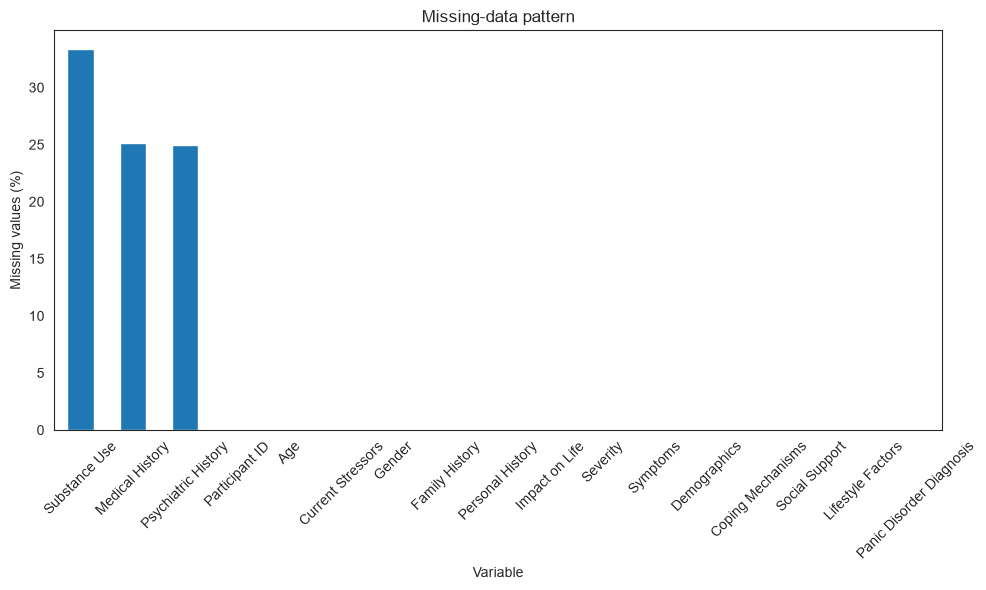

In [20]:
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values("Missing_Percentage", ascending=False)

display(missing)

plt.figure(figsize=(10,6))

missing["Missing_Percentage"].plot(kind="bar")

plt.ylabel("Missing values (%)")
plt.xlabel("Variable")
plt.title("Missing-data pattern")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Saved → reports\figures\03_missing_values_heatmap.png


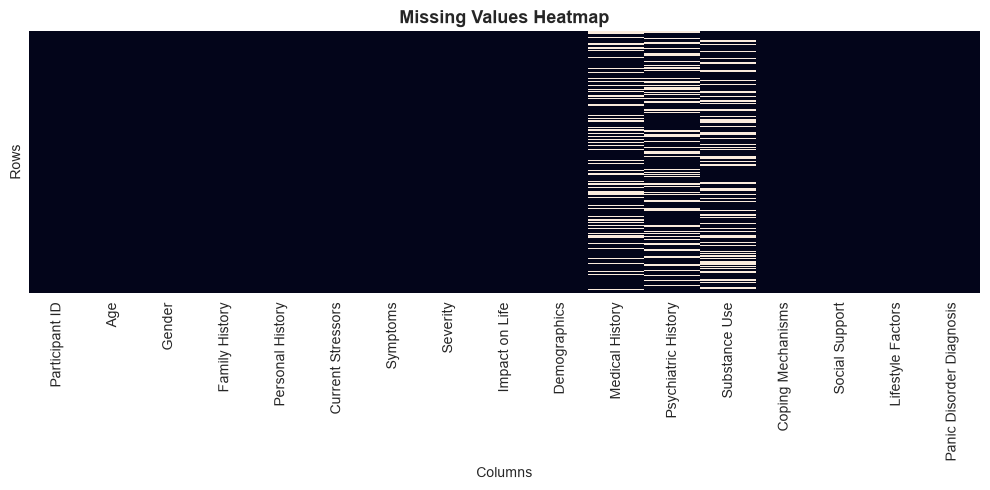

In [21]:
fig = viz.plot_missing_values_heatmap(df)

### 2.3 Duplicates

In [22]:
print("=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["Participant ID"].duplicated().sum())

=== Duplicates ===
Duplicate rows: 0
Duplicate load IDs: 20000


### 2.4 Unique values

In [23]:
print("=== Unique values ===")
df.nunique().sort_values()

=== Unique values ===


Family History                   2
Gender                           2
Personal History                 2
Demographics                     2
Substance Use                    2
Panic Disorder Diagnosis         2
Severity                         3
Medical History                  3
Psychiatric History              3
Social Support                   3
Lifestyle Factors                3
Impact on Life                   3
Current Stressors                3
Coping Mechanisms                4
Symptoms                         5
Age                             48
Participant ID              100000
dtype: int64

Saved → reports\figures\06_unique_values_barchart.png


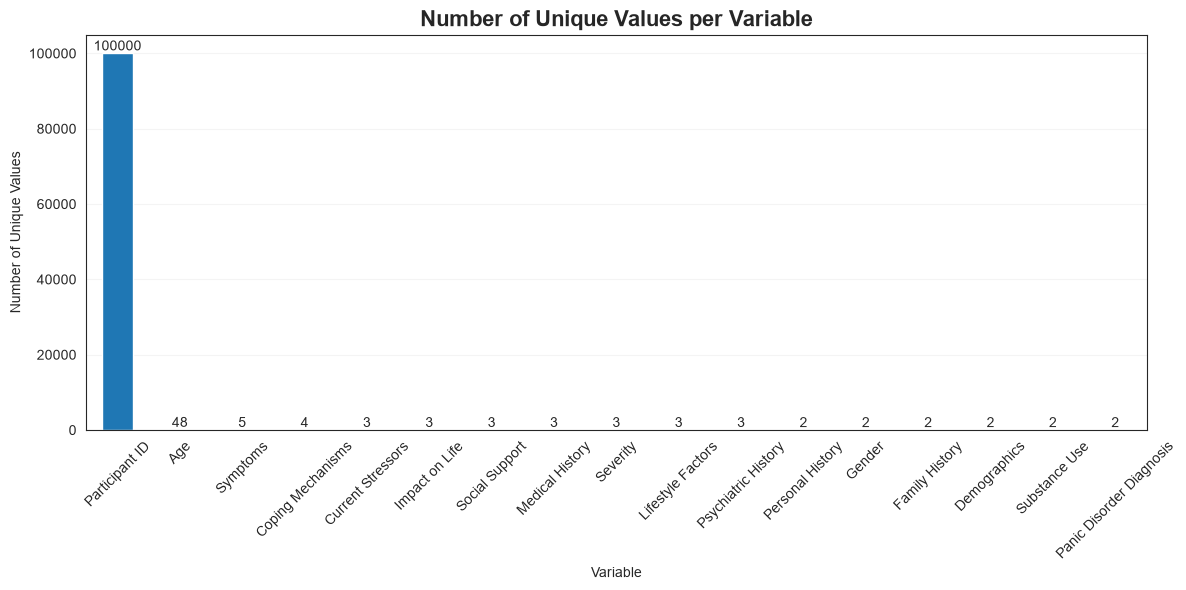

In [24]:
fig = viz.plot_unique_values(df)

### 2.5 Numerical distributions

In [25]:
print("=== df.describe() ===")
df.describe().T

=== df.describe() ===


,count,mean,std,min,25%,50%,75%,max
Participant ID,120000.0000,43333.8333,30368.2385,1.0000,15000.7500,40000.5000,70000.2500,100000.0000
Age,120000.0000,41.4601,13.8473,18.0000,29.0000,42.0000,53.0000,65.0000
Panic Disorder Diagnosis,120000.0000,0.0427,0.2022,0.0000,0.0000,0.0000,0.0000,1.0000


### 2.6 Categorical distributions

In [26]:
print("=== df.describe() for categorical/object columns ===")
df.describe(include="object").T

=== df.describe() for categorical/object columns ===


,count,unique,top,freq
Gender,120000,2,Male,60008
Family History,120000,2,No,60001
Personal History,120000,2,No,60183
Current Stressors,120000,3,Low,40117
Symptoms,120000,5,Dizziness,24173
Severity,120000,3,Severe,40089
Impact on Life,120000,3,Significant,40088
Demographics,120000,2,Rural,60006
Medical History,89826,3,Diabetes,30060
Psychiatric History,90090,3,Bipolar disorder,30053


Saved → reports\figures\05_barplot_categorical_distributions.png


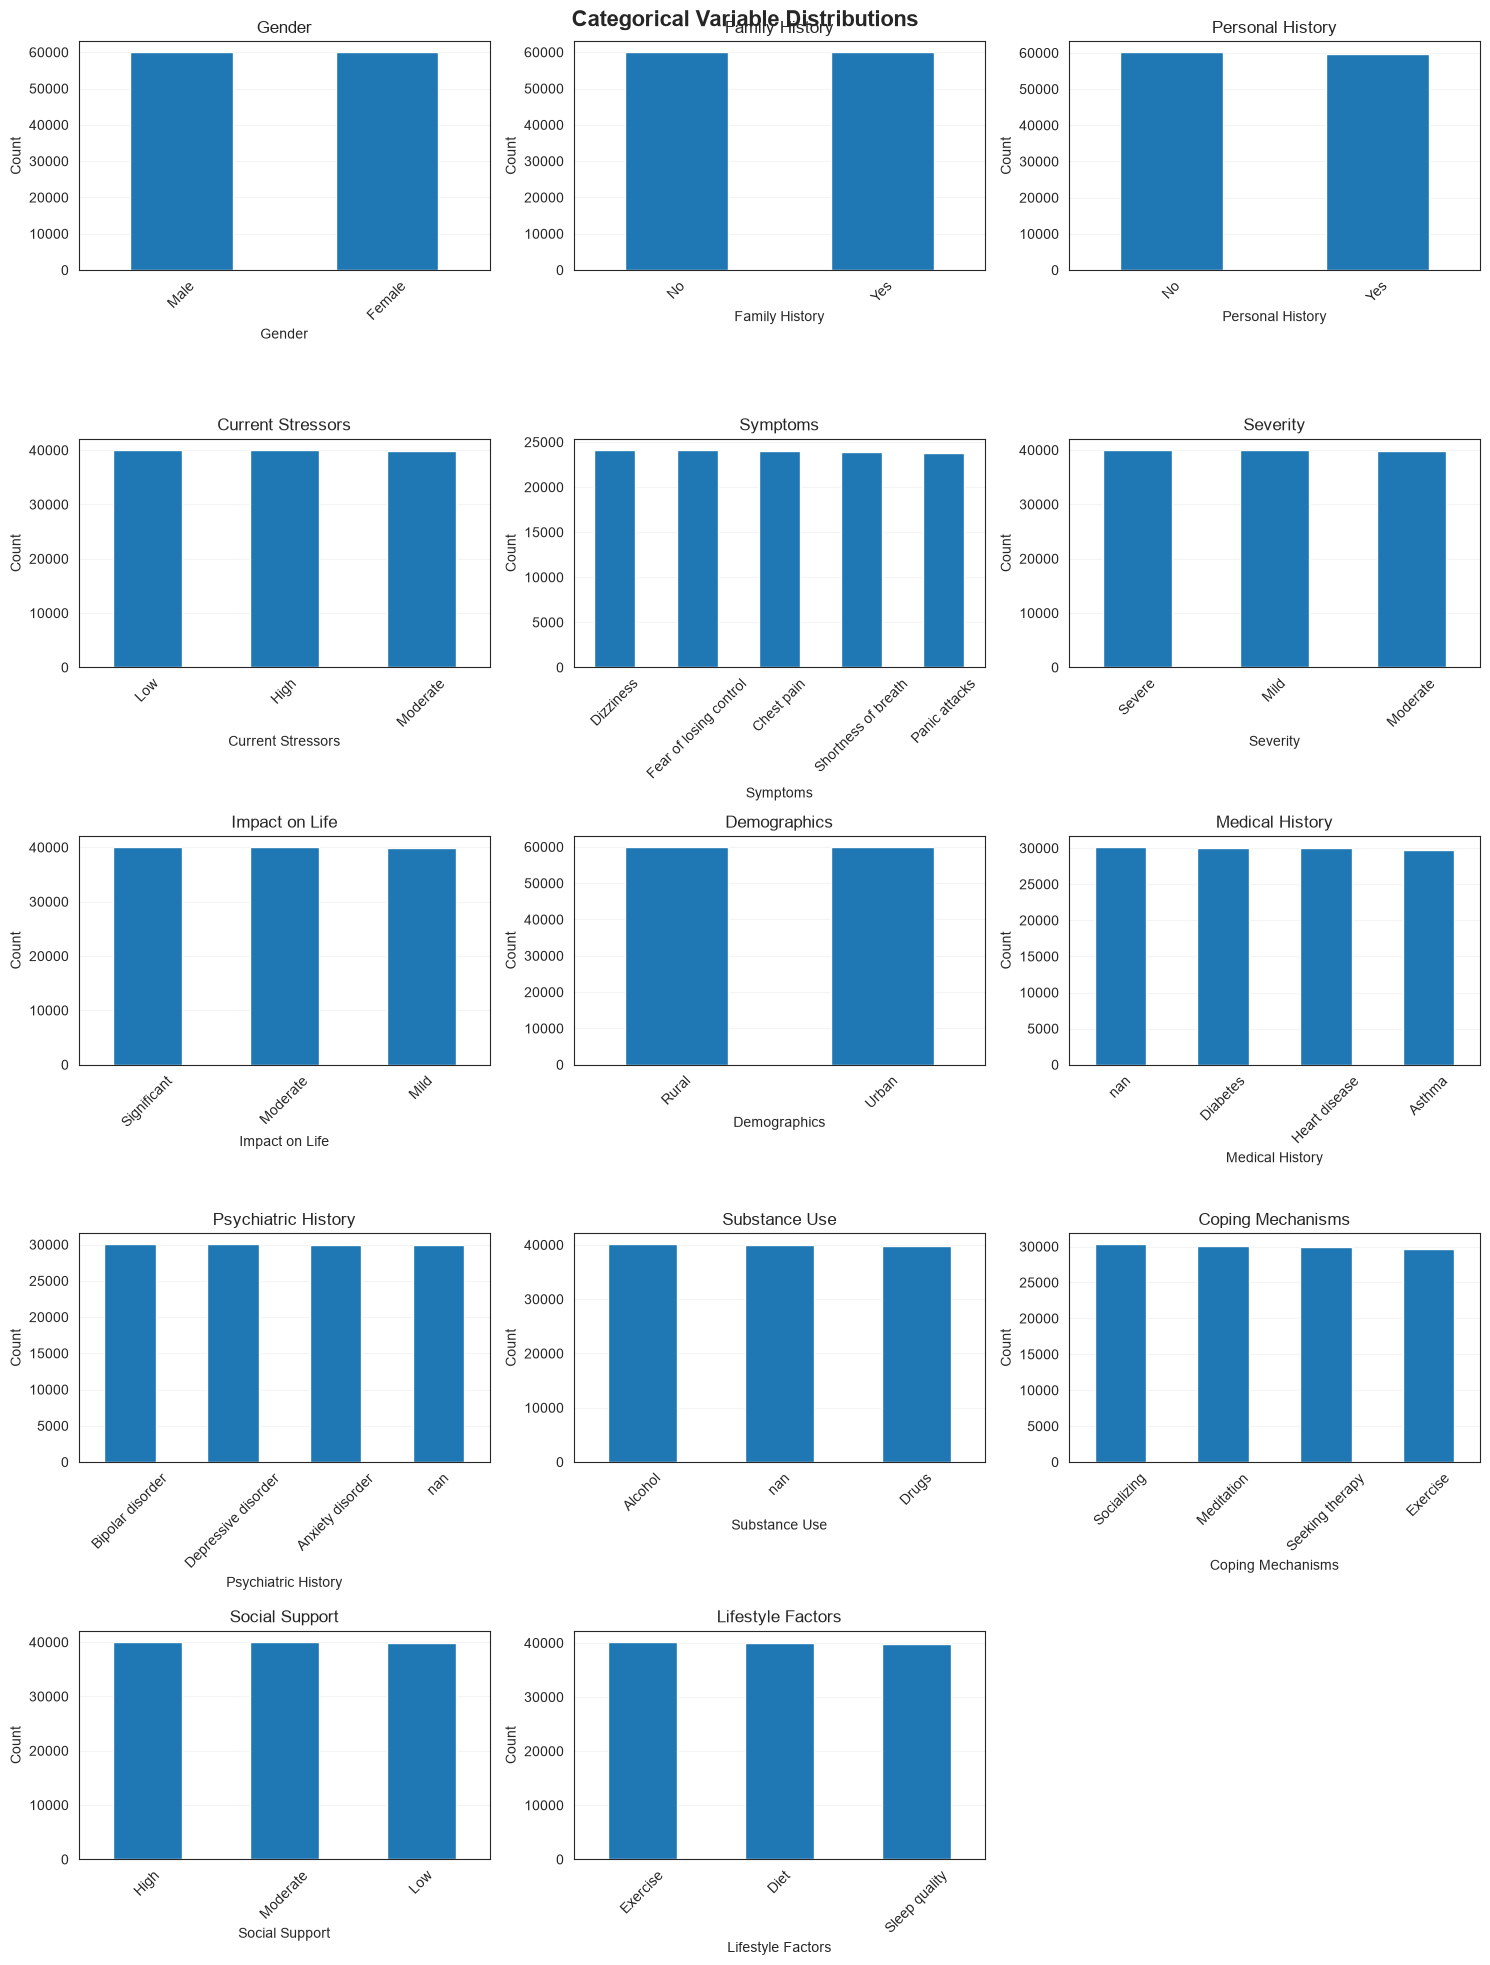

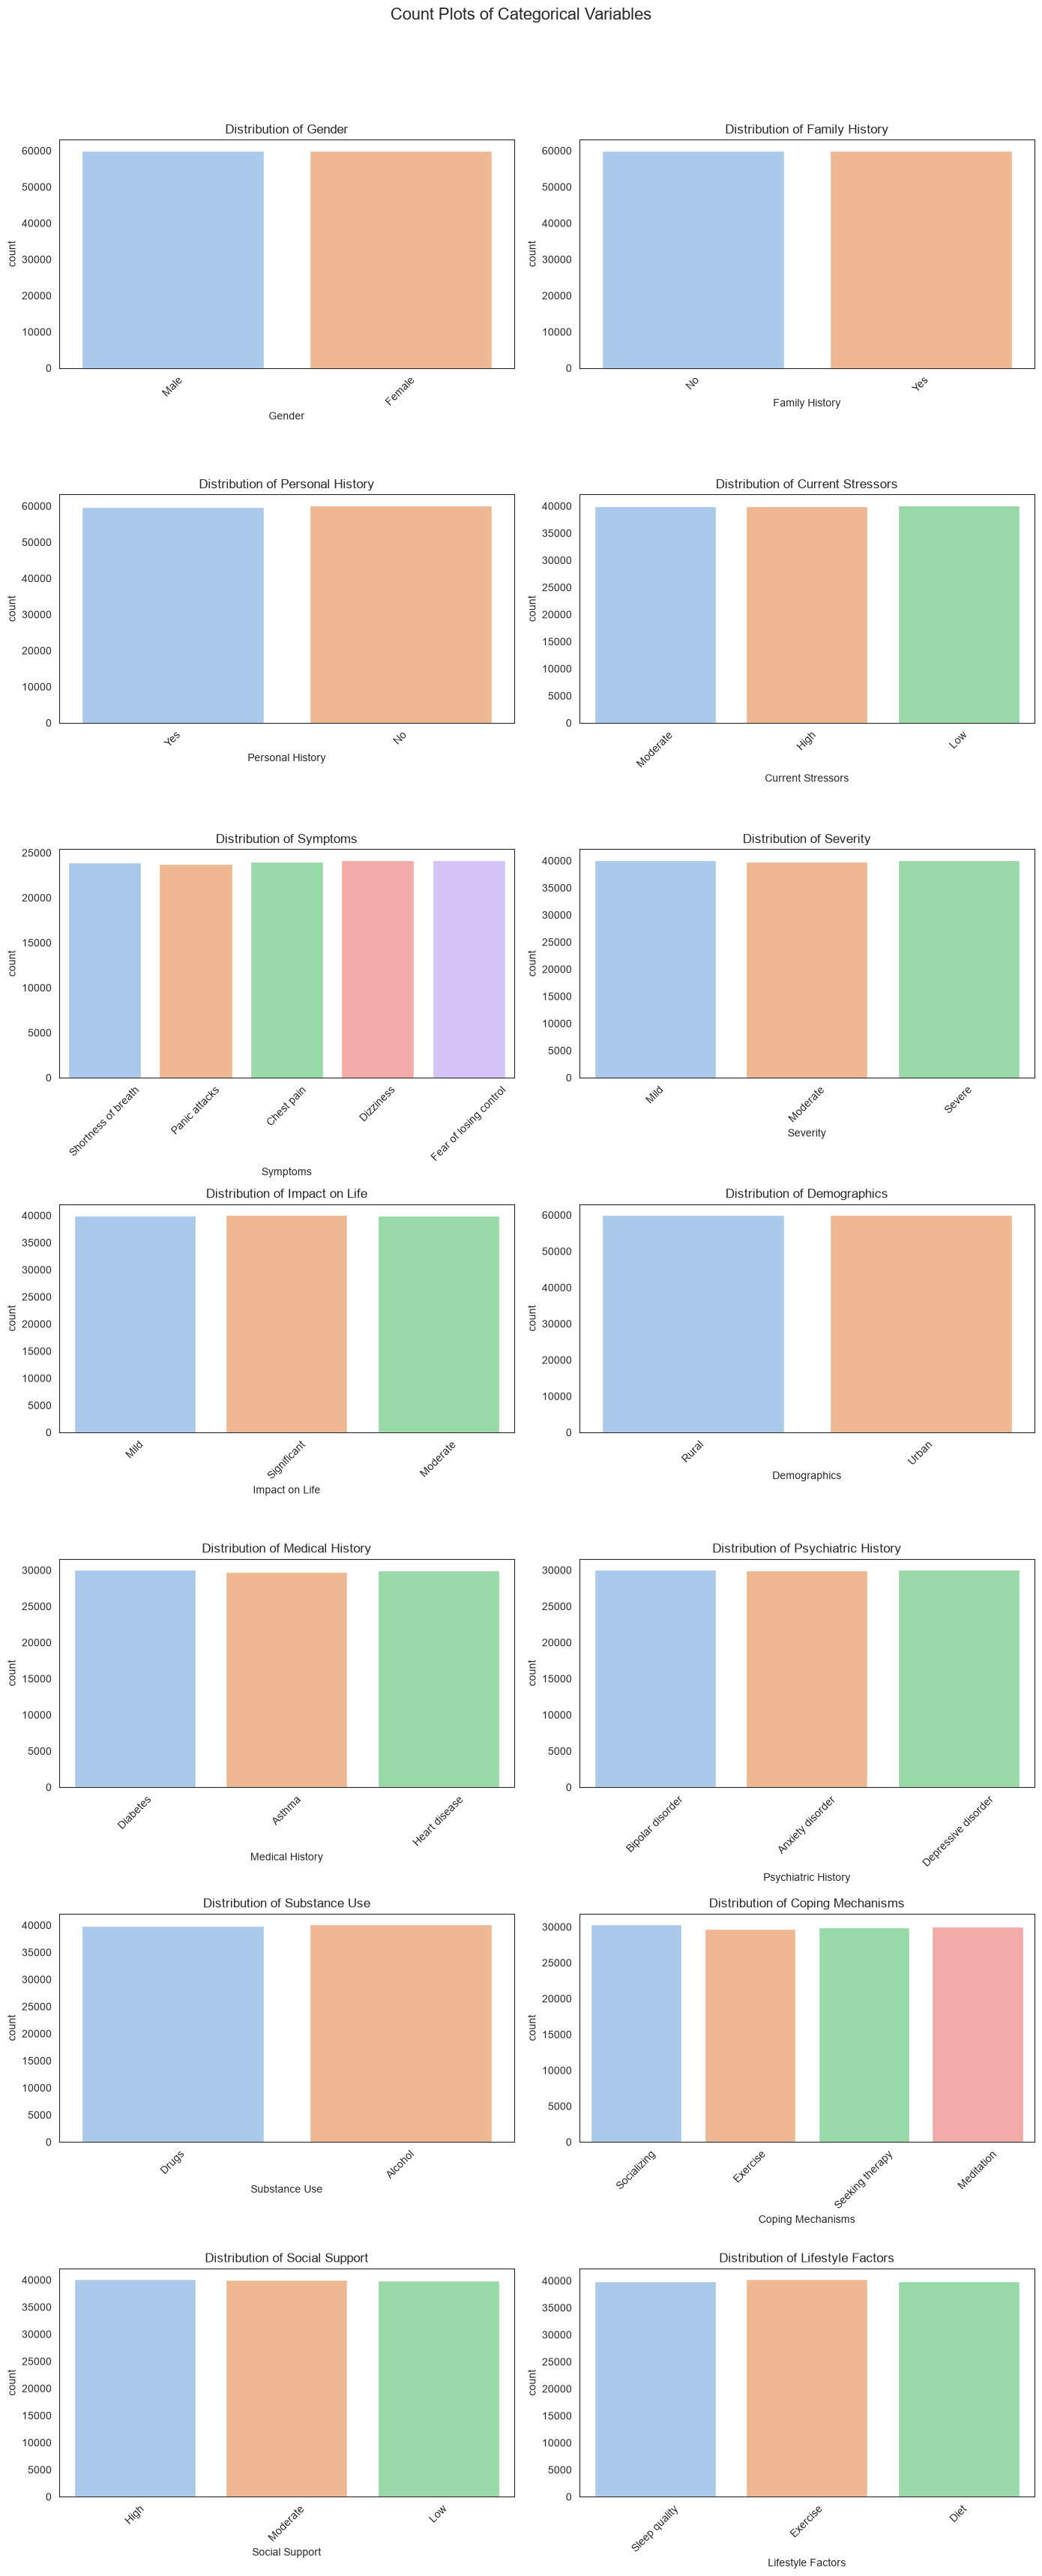

In [27]:
fig=viz.plot_categorical_distributions(df)
plt.show()

# 3. Count plots for categorical variables
plt.figure(figsize=(14, 35))
plt.suptitle("Count Plots of Categorical Variables", fontsize=16)
columns = df.select_dtypes(include=["object", "category", "bool"]).columns.drop(["Participant ID"], errors="ignore").tolist()          
for i, col in enumerate(columns):
    plt.subplot(7, 2, i + 1)
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 2.7 Outliers

In [28]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()

target = "Panic Disorder Diagnosis"

numerical_columns.remove(target)

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Participant ID: 0 outliers
Age: 0 outliers


Saved → reports\figures\07_boxplots_numerical_variables.png


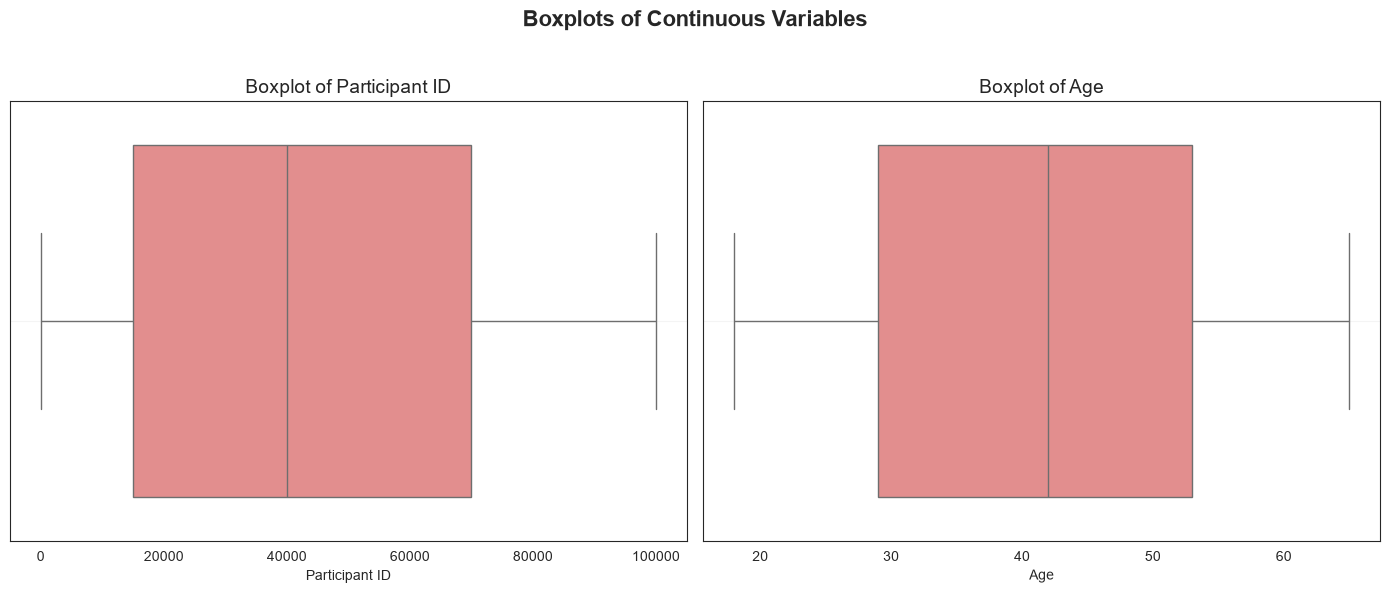

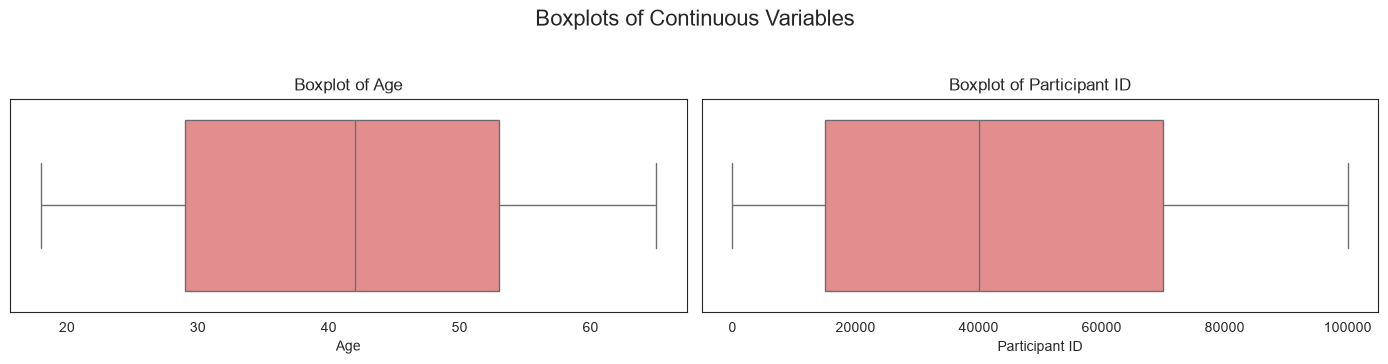

In [29]:
fig= viz.plot_boxplots(df, target="Panic Disorder Diagnosis")
plt.show()

# 2. Boxplots for continuous variables
plt.figure(figsize=(14, 6))
plt.suptitle("Boxplots of Continuous Variables", fontsize=16)
for i, col in enumerate(['Age', 'Participant ID']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 2.8 Target distribution

In [30]:
print("=== Target exploration ===")
df["Participant ID"].describe()

target_counts = df["Panic Disorder Diagnosis"].value_counts()

print(target_counts)

print(
    df["Panic Disorder Diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
)

=== Target exploration ===
Panic Disorder Diagnosis
0    114874
1      5126
Name: count, dtype: int64
Panic Disorder Diagnosis
0   95.7283
1    4.2717
Name: proportion, dtype: float64


Saved → reports\figures\02_histogram_target_distributionPanic Disorder Diagnosis.png


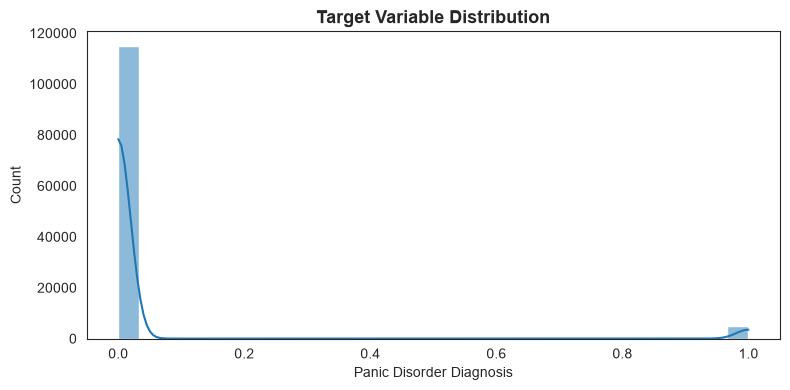

In [31]:
fig = viz.plot_target_distribution(df,"Panic Disorder Diagnosis",title="Target Variable Distribution")

### 2.9 Correlations
#### 2.9.1 Numerical features with Target


Saved → reports\figures\08_numerical_features_vs_target.png


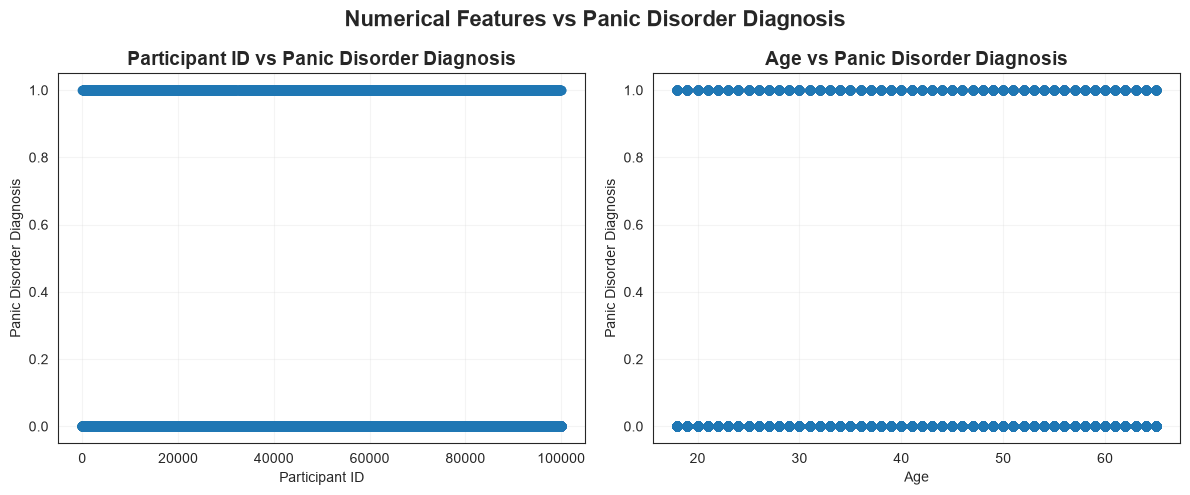

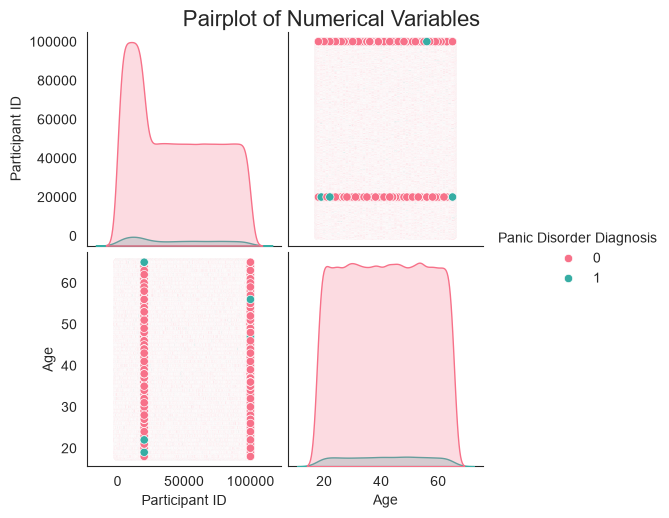

In [32]:
fig = viz.plot_numerical_features_vs_target(
    df,
    target="Panic Disorder Diagnosis"
)

plt.show()

sns.pairplot(df[['Participant ID', 'Age','Panic Disorder Diagnosis']], diag_kind='kde', palette='husl', hue = 'Panic Disorder Diagnosis')
plt.suptitle("Pairplot of Numerical Variables", y=1.02, fontsize=16)
plt.show()

#### 2.9.2 Categorical features with Target


Saved → reports\figures\09_categorical_features_vs_target.png


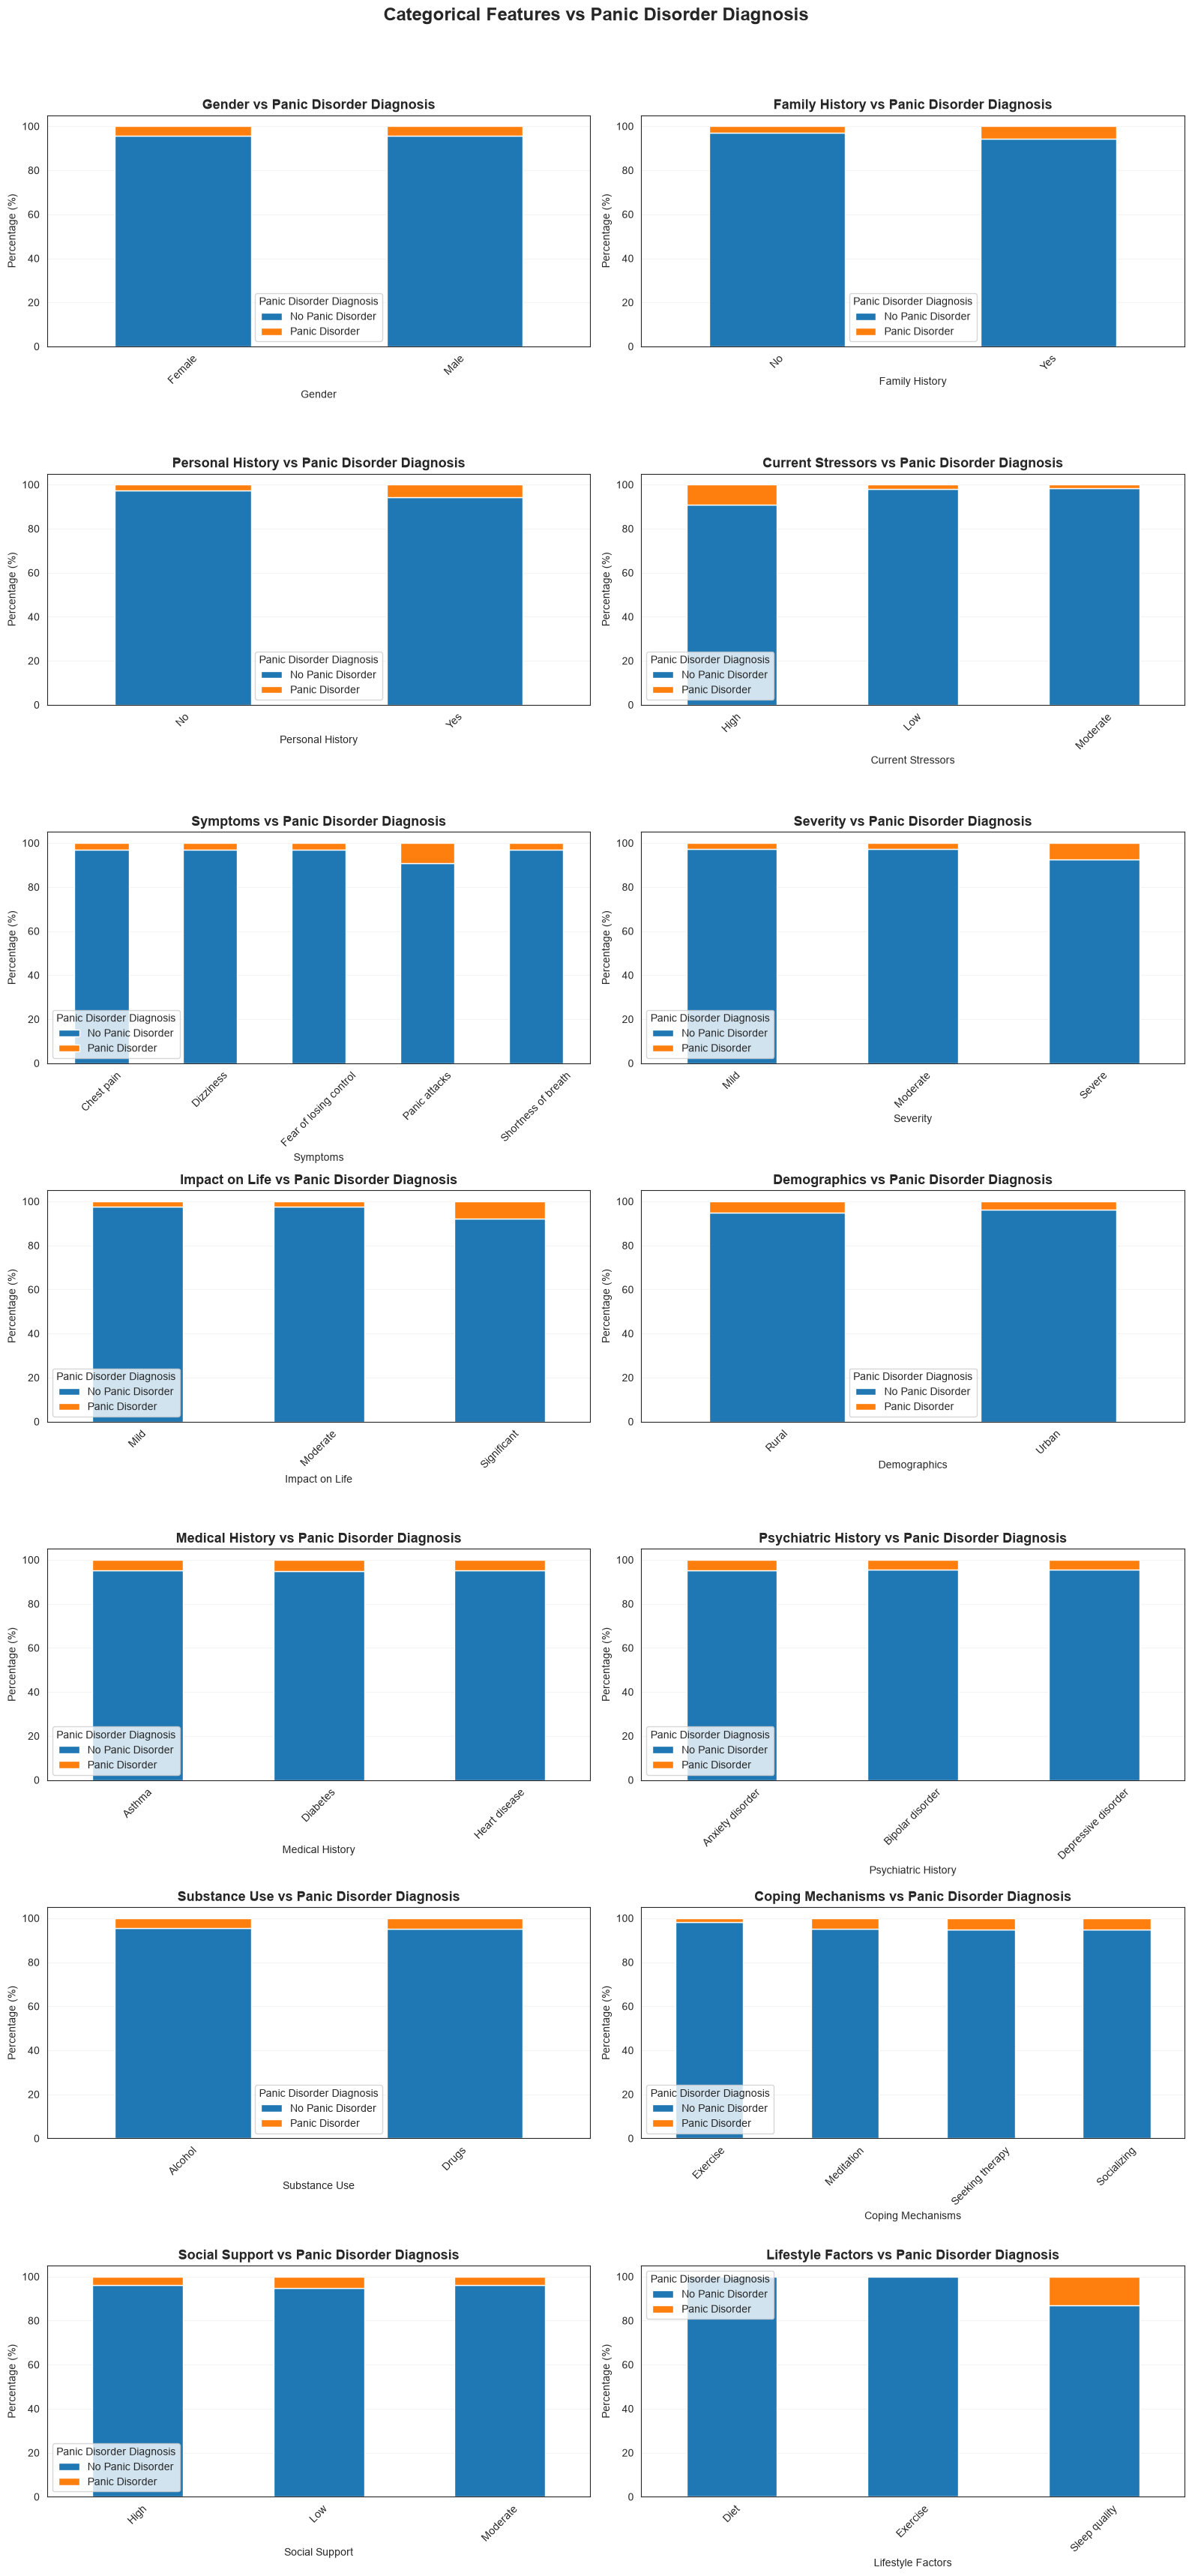

In [33]:
fig = viz.plot_categorical_features_vs_target(
    df,
    target="Panic Disorder Diagnosis"
)

plt.show()

#### 2.9.3 Numerical features with Numerical features


Saved → reports\figures\10_correlation_heatmap.png


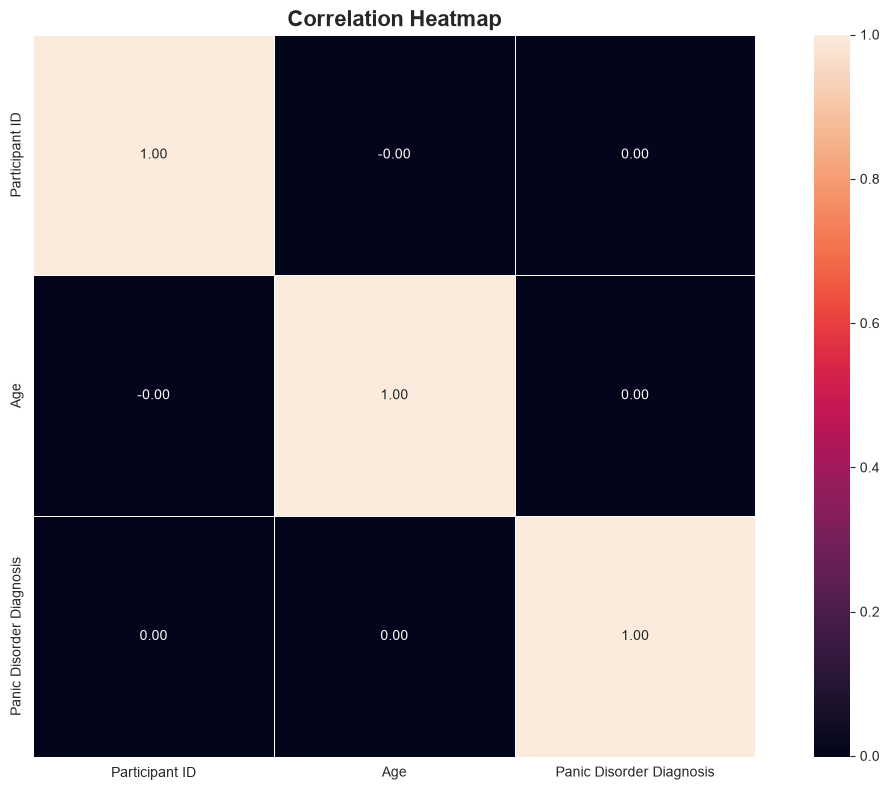

In [34]:
fig = viz.plot_correlation_heatmap(df)

plt.show()

### 2.10 Analyze numerical variable: Age


2026-10-02 14:20:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-02 14:20:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved → reports\figures\12_histogram_age_distribution.png
Saved → reports\figures\13_boxplot_age_by_target.png
Saved → reports\figures\14_countplot_lifestyle_factors_by_target.png


,count,mean,std,min,25%,50%,75%,max
Panic Disorder Diagnosis,,,,,,,,
0,114874.0000,41.4595,13.8510,18.0000,29.0000,41.0000,53.0000,65.0000
1,5126.0000,41.4750,13.7635,18.0000,30.0000,42.0000,53.0000,65.0000


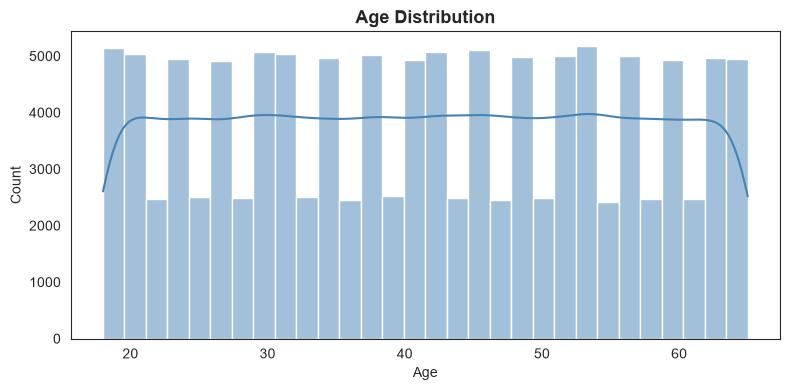

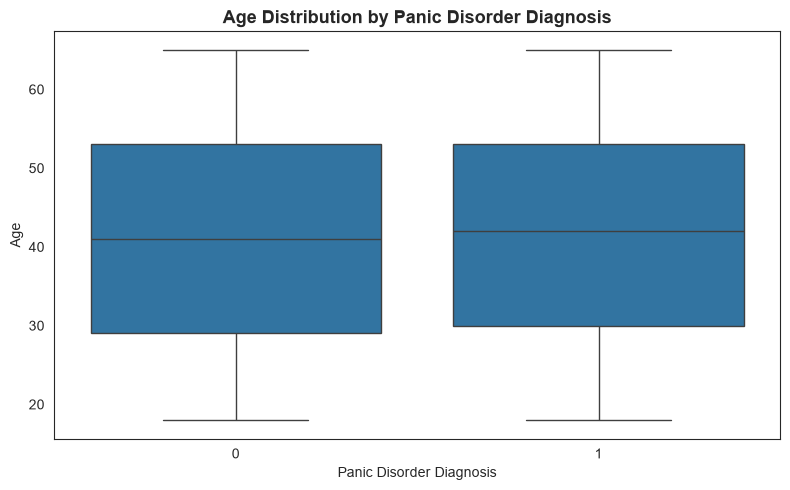

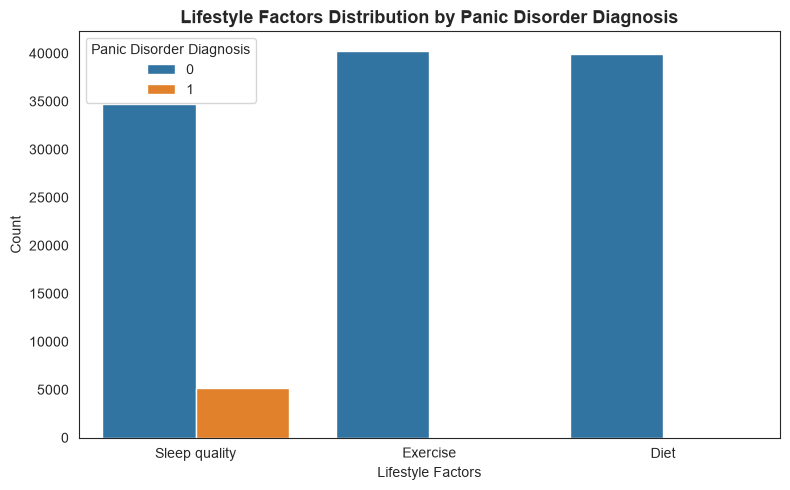

In [35]:
##  Age ditribution
fig=viz.plot_age_distribution(df)

## Age by target

fig =viz.plot_distribution_by_target(
    df,
    feature="Age",
    target="Panic Disorder Diagnosis",
)

fig=viz.plot_categorical_by_target(
    df,
    feature="Lifestyle Factors",
    target="Panic Disorder Diagnosis",
)
df.groupby("Panic Disorder Diagnosis")["Age"].describe()

So age alone appears to provide very little discrimination.

 ### 2.11 Target rate by feature

Saved → reports\figures\11_Target_rate_by_feature_Gender.png
Saved → reports\figures\11_Target_rate_by_feature_Family History.png
Saved → reports\figures\11_Target_rate_by_feature_Personal History.png
Saved → reports\figures\11_Target_rate_by_feature_Current Stressors.png
Saved → reports\figures\11_Target_rate_by_feature_Symptoms.png
Saved → reports\figures\11_Target_rate_by_feature_Severity.png
Saved → reports\figures\11_Target_rate_by_feature_Impact on Life.png
Saved → reports\figures\11_Target_rate_by_feature_Demographics.png
Saved → reports\figures\11_Target_rate_by_feature_Medical History.png
Saved → reports\figures\11_Target_rate_by_feature_Psychiatric History.png
Saved → reports\figures\11_Target_rate_by_feature_Substance Use.png
Saved → reports\figures\11_Target_rate_by_feature_Coping Mechanisms.png
Saved → reports\figures\11_Target_rate_by_feature_Social Support.png
Saved → reports\figures\11_Target_rate_by_feature_Lifestyle Factors.png


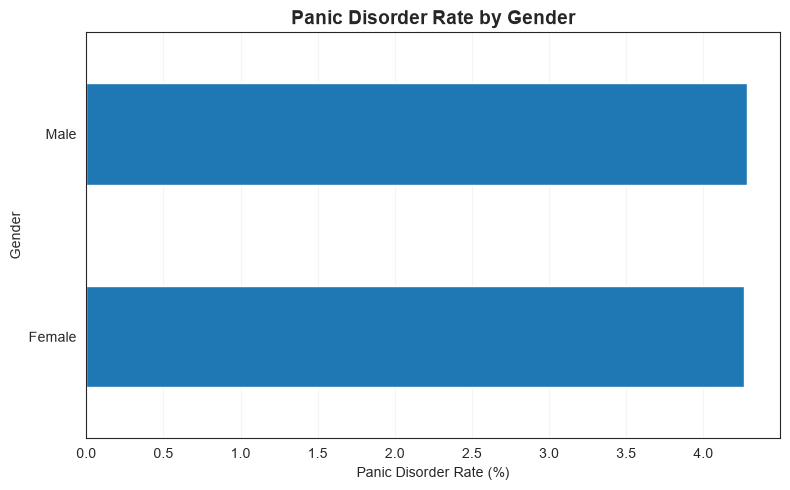

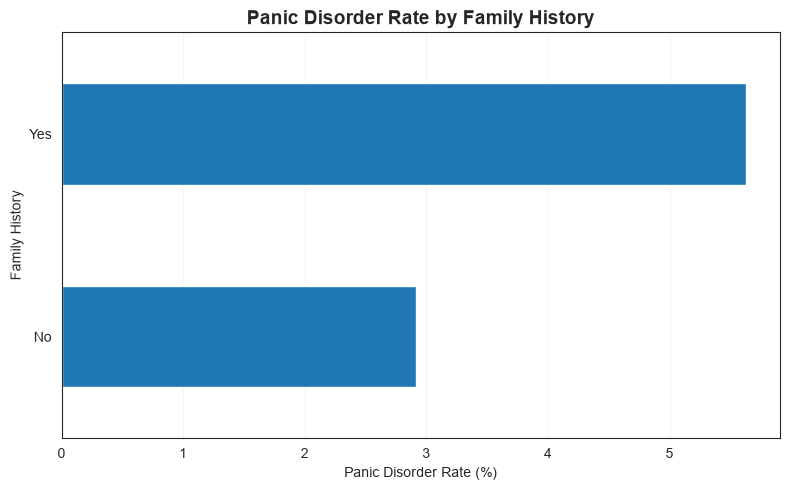

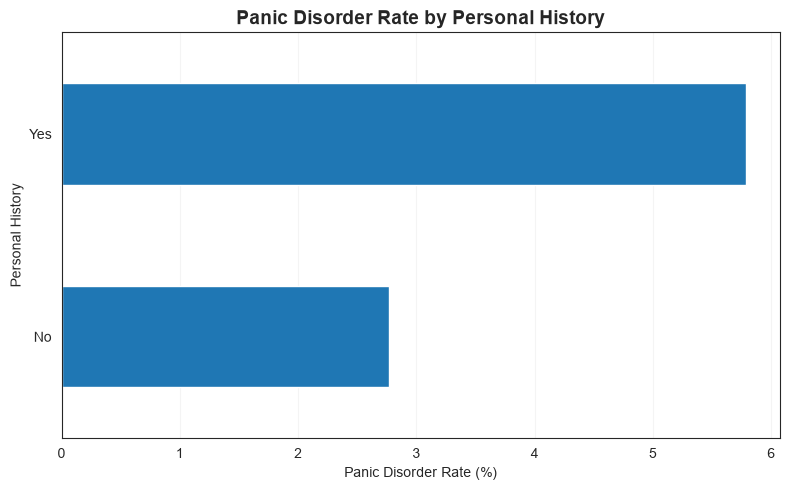

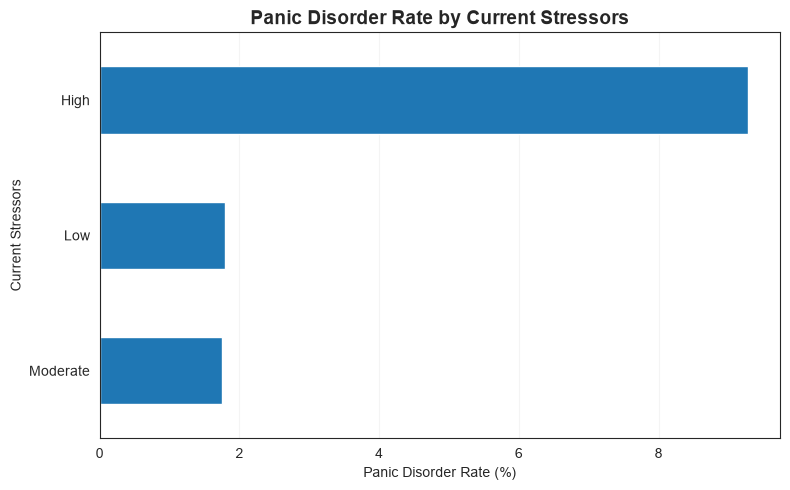

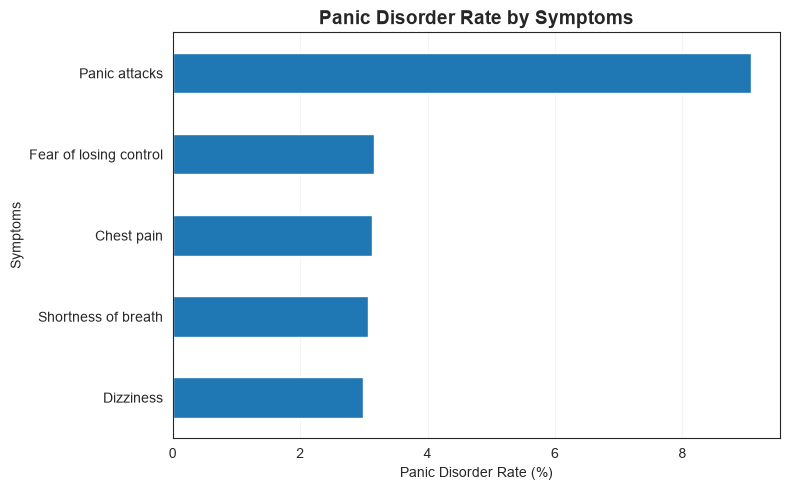

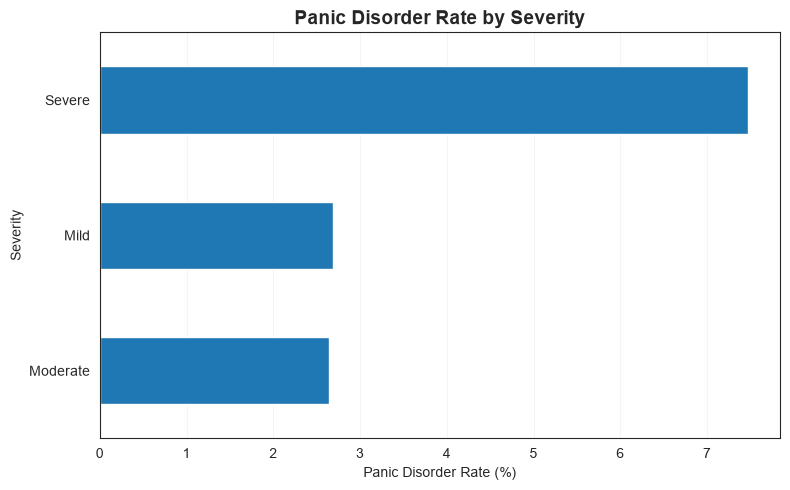

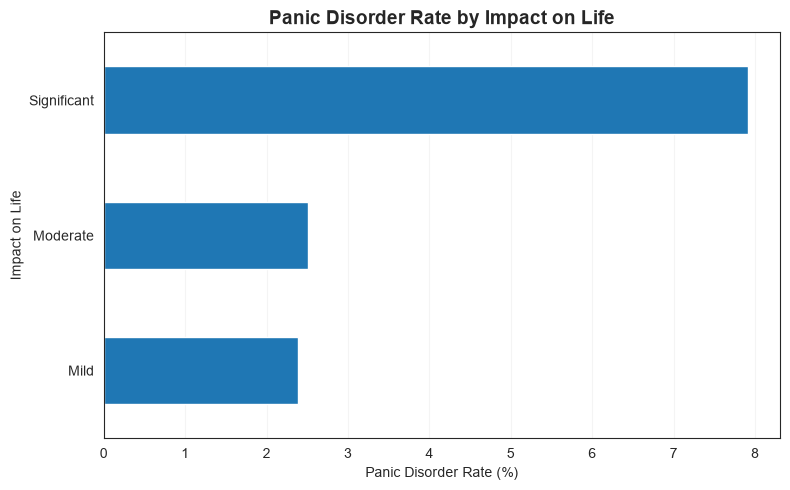

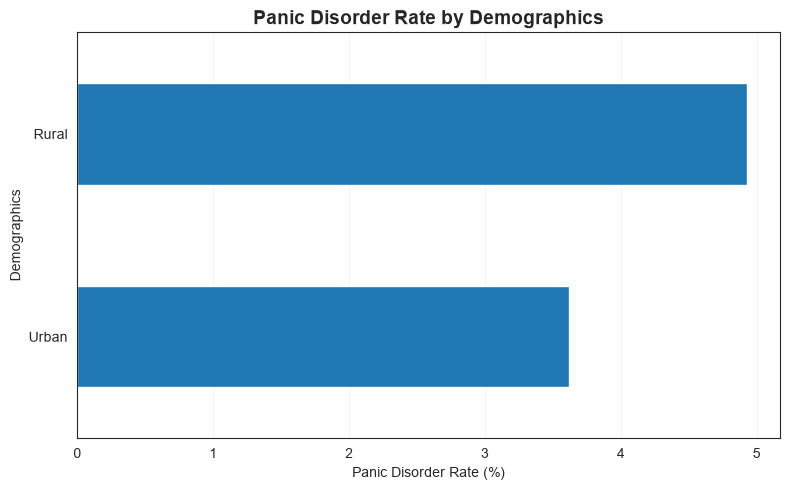

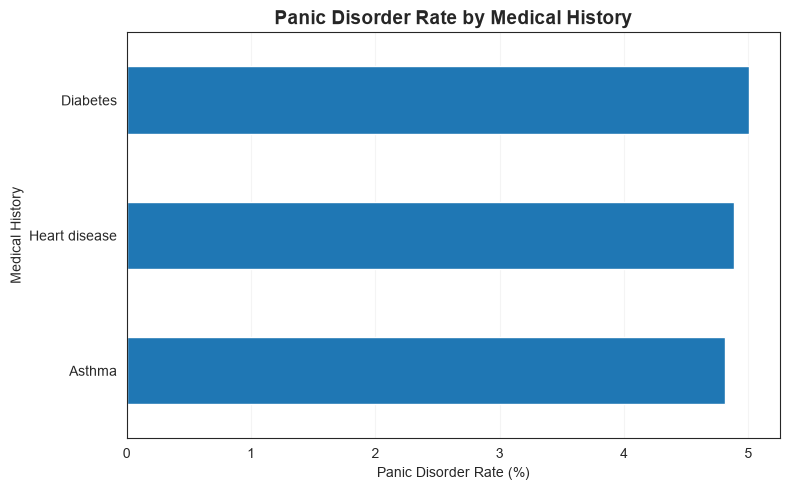

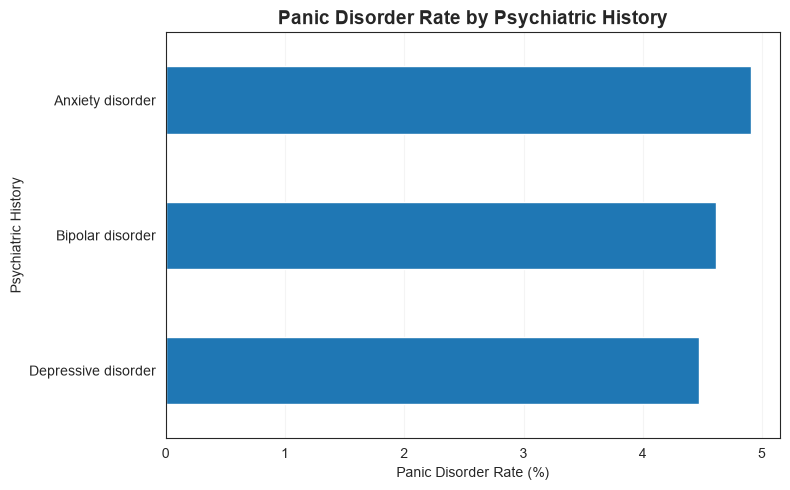

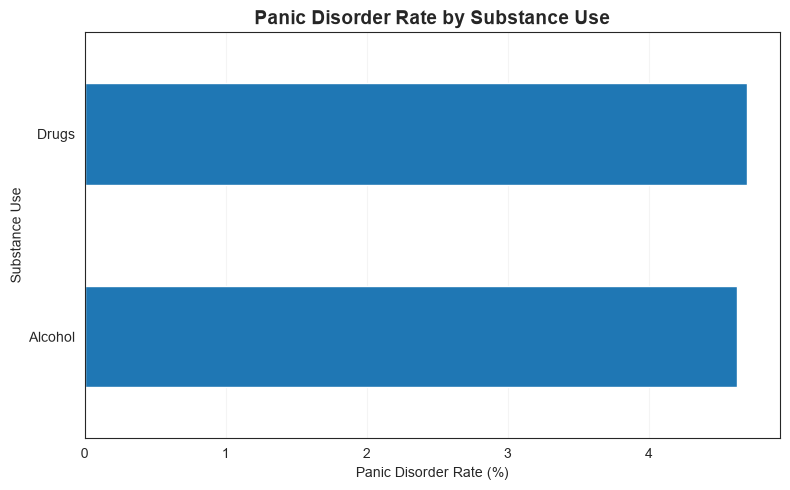

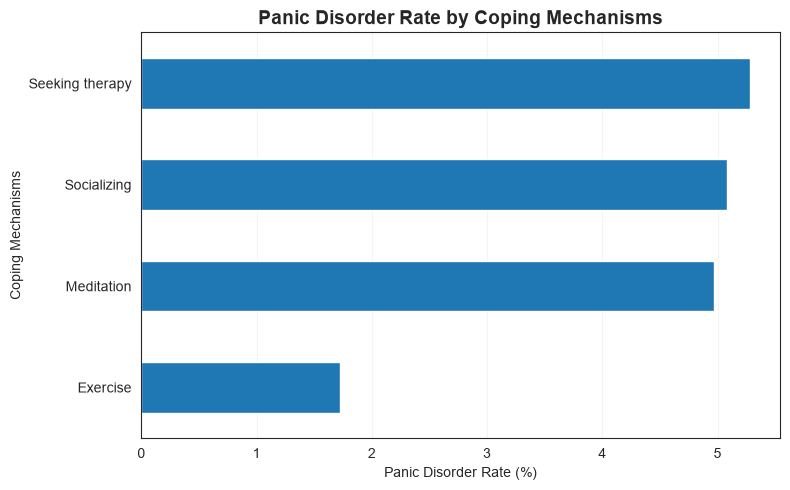

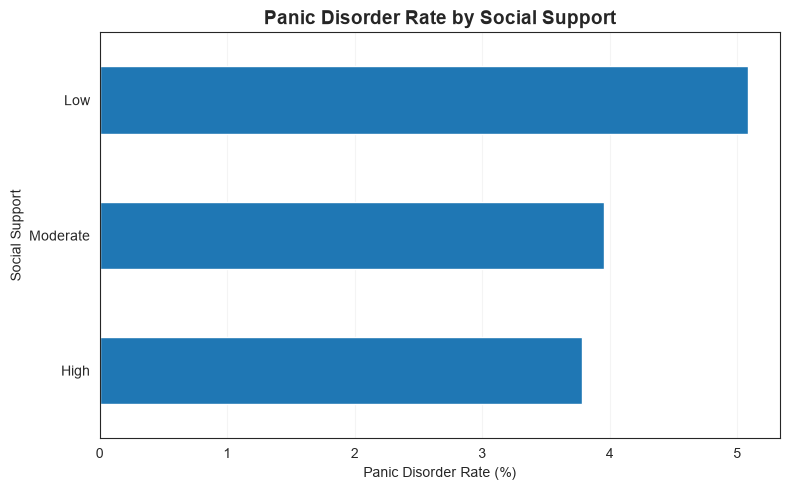

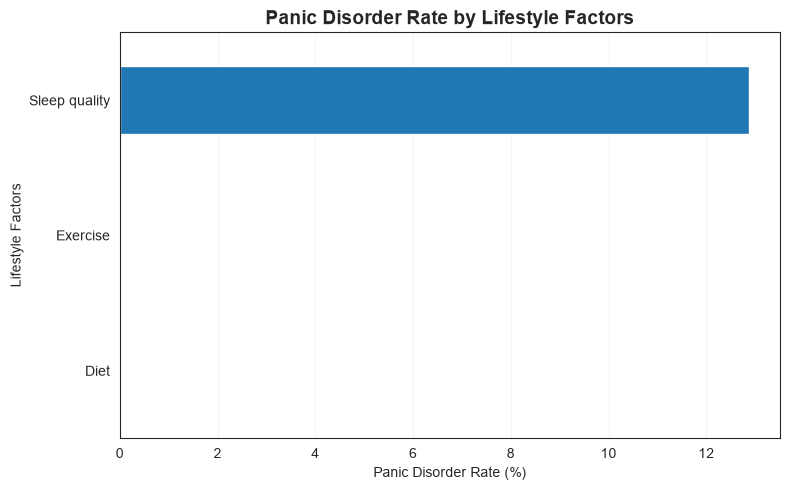

In [36]:
fig=viz.plot_target_rate_by_feature(df,target="Panic Disorder Diagnosis")

In [37]:
pd.crosstab(
    df["Lifestyle Factors"],
    df["Panic Disorder Diagnosis"],
    normalize="index"
) * 100

pd.crosstab(
    df["Lifestyle Factors"],
    df["Panic Disorder Diagnosis"]
)

Panic Disorder Diagnosis,0,1
Lifestyle Factors,,
Diet,39903,0
Exercise,40255,0
Sleep quality,34716,5126


 ### 2.12 Dataset overview table

Saved → reports\figures\01_overview_table.png


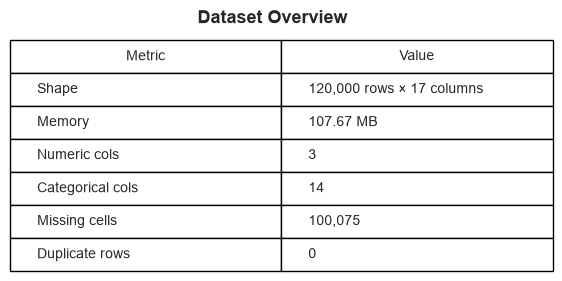

In [38]:
fig = viz.plot_overview_table(df)
plt.show()


### 2.13 Leakage Audit

In [39]:
leak = LeakageAudit(config_path="../config.yaml")
deterministic_summary, chi_results, age_results = leak.run_audit(df)

display(deterministic_summary)
display(chi_results)
display(age_results)



2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | LeakageAudit initialized. Target column: 'Panic Disorder Diagnosis'
2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | LEAKAGE / SYNTHETIC-RULE AUDIT
2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | Investigation 1: Category-level target rates and deterministic patterns.
2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | Starting Investigation 1: category-level target rate audit.
2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | Investigation 1 completed for 14 categorical predictors.
2026-10-02 14:20:06 | INFO     | src.analysis.leakage_audit | Investigation 2: Statistical association testing (Chi-square + Cramér's V).
2026-10-02 14:20:06 | INFO     | src.analysis.statistical_tests | StatisticalTests initialized with target: Panic Disorder Diagnosis
2026-10-02 14:20:06 | INFO     | src.analysis.statistical_tests | Chi-square analysis completed for 14 features.
2026-10-02 14:20:

,Feature,Category,Count,Positive_Count,Positive_Rate
0,Lifestyle Factors,Diet,39903,0,0.0000
1,Lifestyle Factors,Exercise,40255,0,0.0000


,Feature,Chi2,Degrees_of_Freedom,p_value,Cramers_V
0,Current Stressors,3665.3922,2,0.0000,0.1747
1,Impact on Life,1949.6371,2,0.0000,0.1274
2,Severity,1504.5022,2,0.0000,0.1119
3,Symptoms,1674.0892,4,0.0000,0.1180
4,Lifestyle Factors,10773.1783,2,0.0000,0.2996
5,Personal History,666.6325,1,0.0000,0.0745
6,Coping Mechanisms,629.9313,3,0.0000,0.0723
7,Family History,538.1871,1,0.0000,0.0669
8,Medical History,345.6991,3,0.0000,0.0534
9,Psychiatric History,142.6135,3,0.0000,0.0341


,Feature,Correlation,p_value,Sample_Size
0,Age,0.0002,0.9372,120000


 ### Key observations from EDA

The exploratory data analysis provided several important insights that will guide the preprocessing and modeling stages.

- The dataset contains **100,000 observations**, and the target variable, `Panic Disorder Diagnosis`, is binary. The positive class represents approximately **4.29%** of the observations, indicating a substantial class imbalance. Therefore, model evaluation should not rely on accuracy alone.

- `Participant ID` is an identifier rather than a meaningful predictive variable, so it will be excluded from the modeling features.

- The numerical variables were examined using descriptive statistics, distribution plots, boxplots, and correlation analysis. These checks were used to identify unusual values, potential outliers, and relationships between variables.

- The **age distribution** is relatively broad across the observed age range. However, age shows almost no relationship with the diagnosis in this dataset (**point-biserial correlation = -0.0005, p = 0.8739**). This suggests that age alone provides very limited information for distinguishing between the two target classes.

- The categorical variables were investigated through frequency distributions and their relationships with the target. In particular, `Lifestyle Factors` showed a relatively strong association with the diagnosis (**χ² = 9059.79, df = 2, Cramér's V = 0.3010**), making it an important variable to investigate further.

- `Diet` and `Exercise` contain **zero positive cases** for the diagnosis. This unusual pattern does not automatically imply that these variables should be removed, but it requires further investigation because it may indicate a deterministic relationship or a synthetic rule in the dataset.

- Several other groups of variables, including **Symptoms, Severity, Impact on Life, Personal History, and Current Stressors**, were also examined because of their potentially strong relationships with the target.

- Because some variables showed unusually strong or structured relationships with the diagnosis, a **data leakage / synthetic-rule audit** was conducted before model training. The purpose of this analysis was to determine whether these relationships could be explained by legitimate predictive information or by artificially generated/deterministic relationships.

Overall, the EDA indicates that the dataset contains potentially informative categorical features as well as a highly imbalanced target. The findings from the leakage audit will therefore be considered before finalizing the feature set and proceeding to model training.